In [14]:
# Cell 1: Load and preprocess data
import pandas as pd
from sklearn.model_selection import train_test_split

# Load training dataset
train_file = r"train.csv"
df = pd.read_csv(train_file)

# Drop unnecessary columns
df = df.drop(['Contract', 'PaymentMethod', 'InternetService'], axis=1)

# Map categorical features to numeric
binary_map = {'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0}
cols_to_map = ['gender','Partner','Dependents','PhoneService','MultipleLines',
               'OnlineBackup','OnlineSecurity','DeviceProtection','TechSupport',
               'StreamingMovies','StreamingTV','PaperlessBilling']

for col in cols_to_map:
    df[col] = df[col].map(binary_map)



,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",12
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

AUC: 0.9067442329348098


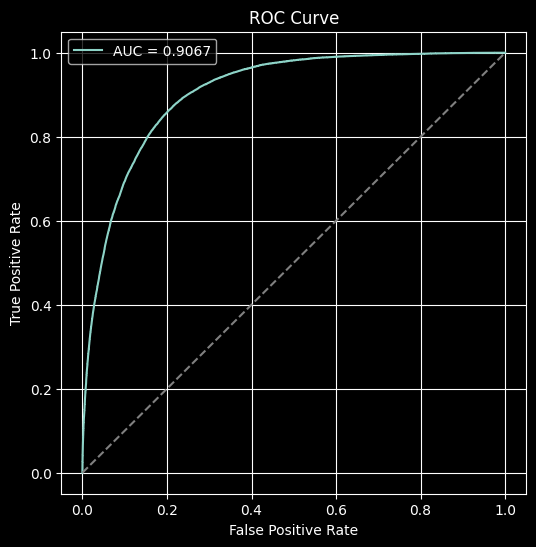

In [21]:
# Convert y_test to 0/1
y_test_num = y_test.map({'No': 0, 'Yes': 1})

# Predict probabilities
y_prob = model.predict_proba(X_test)[:, 1]

# Compute AUC
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

auc = roc_auc_score(y_test_num, y_prob)
print("AUC:", auc)

# Optional ROC curve
fpr, tpr, thresholds = roc_curve(y_test_num, y_prob)
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

C:\Users\rhysj\AppData\Local\Programs\Python\Python314\Lib\site-packages\xgboost\training.py:200: UserWarning: [10:18:00] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost AUC: 0.9101798858409462


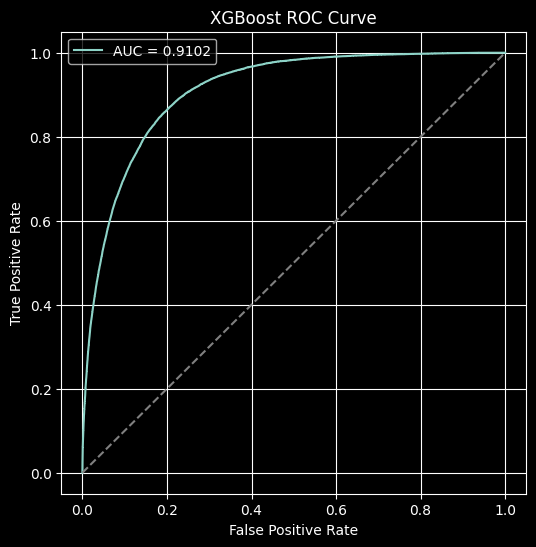

In [23]:
# Cell: Train XGBoost model (numeric target)
import xgboost as xgb
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Convert target to numeric 0/1
y_train_num = y_train.map({'No': 0, 'Yes': 1})
y_test_num = y_test.map({'No': 0, 'Yes': 1})

# Initialize XGBoost classifier
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

# Train XGBoost
xgb_model.fit(X_train, y_train_num)

# Predict probabilities for AUC
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

# Compute AUC
auc_xgb = roc_auc_score(y_test_num, y_prob_xgb)
print("XGBoost AUC:", auc_xgb)

# Optional: plot ROC curve
fpr, tpr, thresholds = roc_curve(y_test_num, y_prob_xgb)
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {auc_xgb:.4f}")
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("XGBoost ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

In [33]:
import xgboost as xgb
from sklearn.metrics import roc_auc_score

# Convert target to numeric
y_train_num = y_train.map({'No':0, 'Yes':1})
y_test_num = y_test.map({'No':0, 'Yes':1})

# DMatrix
dtrain = xgb.DMatrix(X_train, label=y_train_num)
dtest = xgb.DMatrix(X_test, label=y_test_num)

params_xgb = {
    'objective': 'binary:logistic',
    'max_depth': 6,
    'eta': 0.05,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'eval_metric': 'auc',
    'seed': 42
}

xgb_model = xgb.train(
    params=params_xgb,
    dtrain=dtrain,
    num_boost_round=500,
    evals=[(dtest,'eval')],
    verbose_eval=False
)

y_prob_xgb = xgb_model.predict(dtest)
print("XGBoost done")

XGBoost done


In [36]:
import lightgbm as lgb

# Create datasets
lgb_train = lgb.Dataset(X_train, label=y_train_num)
lgb_eval = lgb.Dataset(X_test, label=y_test_num, reference=lgb_train)

params_lgb = {
    'objective': 'binary',
    'metric': 'auc',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'seed': 42
}

# Train LightGBM (no verbose_eval)
lgb_model = lgb.train(
    params=params_lgb,
    train_set=lgb_train,
    num_boost_round=500,
    valid_sets=[lgb_eval]
)

# Predict probabilities
y_prob_lgb = lgb_model.predict(X_test)
print("LightGBM done")

[LightGBM] [Info] Number of positive: 106913, number of negative: 368442
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.016330 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 871
[LightGBM] [Info] Number of data points in the train set: 475355, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.224912 -> initscore=-1.237268
[LightGBM] [Info] Start training from score -1.237268
LightGBM done


In [37]:
from catboost import CatBoostClassifier

cat_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    eval_metric='AUC',
    random_seed=42,
    verbose=0
)

cat_model.fit(X_train, y_train_num)
y_prob_cat = cat_model.predict_proba(X_test)[:,1]
print("CatBoost done")

CatBoost done


In [38]:
from sklearn.metrics import roc_auc_score

# Simple average ensemble
y_prob_ensemble = (y_prob_xgb + y_prob_lgb + y_prob_cat) / 3

# Compute ensemble AUC
ensemble_auc = roc_auc_score(y_test_num, y_prob_ensemble)
print(f"Ensemble AUC: {ensemble_auc:.4f}")

Ensemble AUC: 0.9105


In [39]:
# Cell 4: Ensemble Submission
import pandas as pd
import numpy as np

# Load test dataset
test_file = r"test.csv"
df_test = pd.read_csv(test_file)

# Preprocess categorical columns (same as training)
for col in cols_to_map:
    df_test[col] = df_test[col].map(binary_map)

# Drop columns not used in training
df_test = df_test.drop(['Contract', 'PaymentMethod', 'InternetService'], axis=1)

# ------------------ Make predictions ------------------
# XGBoost
dtest = xgb.DMatrix(df_test)
y_prob_xgb_test = xgb_model.predict(dtest)

# LightGBM
y_prob_lgb_test = lgb_model.predict(df_test)

# CatBoost
y_prob_cat_test = cat_model.predict_proba(df_test)[:,1]

# Ensemble (average)
y_prob_ensemble_test = (y_prob_xgb_test + y_prob_lgb_test + y_prob_cat_test) / 3

# Convert probabilities to binary predictions (0/1)
submission_preds = (y_prob_ensemble_test >= 0.5).astype(int)

# Optional: convert to 'Yes'/'No' if required by submission
submission_preds_label = np.where(submission_preds==1, 'Yes', 'No')

# Create submission dataframe
submission = pd.DataFrame({
    'id': df_test['id'],
    'Churn': submission_preds_label  # or use submission_preds for 0/1
})

# Save submission
submission.to_csv('submission.csv', index=False)
print("Ensemble submission saved to submission.csv")

Ensemble submission saved to submission.csv


In [42]:
# Convert probabilities to binary predictions (0/1)
submission_preds = (y_prob_ensemble_test >= 0.5).astype(int)

# Create submission dataframe
submission = pd.DataFrame({
    'id': df_test['id'],
    'Churn': submission_preds  # numeric 0/1
})

# Save submission
submission.to_csv('submission.csv', index=False)
print("Ensemble submission saved to submission.csv")

Ensemble submission saved to submission.csv


In [40]:
# Cell: Compare submission with sample_submission.csv

import pandas as pd

# Load sample submission
sample = pd.read_csv('sample_submission.csv')

# Load your submission
submission = pd.read_csv('submission.csv')

# Quick checks
print("Columns in sample submission:", sample.columns.tolist())
print("Columns in your submission:", submission.columns.tolist())

# Check if column names and order match
columns_match = sample.columns.tolist() == submission.columns.tolist()
print("Columns match:", columns_match)

# Check number of rows
print("Number of rows in sample:", len(sample))
print("Number of rows in submission:", len(submission))

# Check if IDs match
ids_match = sample['id'].equals(submission['id'])
print("IDs match:", ids_match)

# Full equality check (True only if everything matches exactly)
submission_matches_sample = submission.equals(sample)
print("Submission matches sample exactly:", submission_matches_sample)

Columns in sample submission: ['id', 'Churn']
Columns in your submission: ['id', 'Churn']
Columns match: True
Number of rows in sample: 254655
Number of rows in submission: 254655
IDs match: True
Submission matches sample exactly: False
